<a href="https://colab.research.google.com/github/akp4533/Stochastic-Interest-Rate-Modelling-and-Prediction-/blob/main/24114015_Stochastic_Interest_Rate_Modelling_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stochastic Interest Rate Modelling and Prediction

Name: Anurag Kishor Patil  
Enrollment Number: 24114015  
Branch: CSE (3rd yr)

This notebook studies the yield curve using exploratory diagnostics, principal component analysis, exact maximum-likelihood calibration of the Cox-Ingersoll-Ross short-rate model, and a CIR++ deterministic shift extension.

The modelling path is :

1. Inspect and clean the yield data.
2. Use EDA and PCA to understand the dominant yield-curve drivers.
3. Calibrate a one-factor CIR model from the 3-month rate.
4. Reconstruct short maturities from the calibrated model.
5. Add a CIR++ maturity shift and compare the fit.

## 1. Environment Setup


In [180]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from scipy.optimize import minimize
from scipy.stats import ncx2
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(7)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="viridis"
)

## 2. Data Loading  


In [181]:
train_file = "https://github.com/akp4533/Stochastic-Interest-Rate-Modelling-and-Prediction-/raw/refs/heads/main/train_data.csv"
test_file = "https://raw.githubusercontent.com/akp4533/Stochastic-Interest-Rate-Modelling-and-Prediction-/refs/heads/main/test_data.csv"
test_3m_file = "https://github.com/akp4533/Stochastic-Interest-Rate-Modelling-and-Prediction-/raw/refs/heads/main/test_data_3M.csv"

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)
test_3m_df = pd.read_csv(test_3m_file)

print(f"Training data shape: {train_df.shape}")
print(f"3M test data shape: {test_3m_df.shape}")
print(f"Test data shape: {test_df.shape}")

Training data shape: (1976, 10)
3M test data shape: (495, 2)
Test data shape: (495, 6)


## 3. Data Quality Check  
Here, all the three datasets i.e test , train and test_3m are checked for any duplicates or missing values

In [182]:
# For train_df
print("train_df")
print("\nColumn Names")
print(list(train_df.columns))

print("\nDuplicate Rows Count")
print(train_df.duplicated().sum())

print("\nDuplicate Dates Count")
print(train_df.duplicated(subset=["Date"]).sum())

print("\nData Types")
print(train_df.dtypes)

print("\nMissing Values Count")
print(train_df.isna().sum())

print("\nUnique Values Count")
print(train_df.nunique())

print("\nMinimum Values")
print(train_df.min())

print("\nMaximum Values")
print(train_df.max())
print("\n")


# For test_df
print("\ntest_df")
print("\nColumn Names")
print(list(test_df.columns))

print("\nDuplicate Rows Count")
print(test_df.duplicated().sum())

print("\nDuplicate Dates Count")
print(test_df.duplicated(subset=["Date"]).sum())

print("\nData Types")
print(test_df.dtypes)

print("\nMissing Values Count")
print(test_df.isna().sum())

print("\nUnique Values Count")
print(test_df.nunique())

print("\nMinimum Values")
print(test_df.min())

print("\nMaximum Values")
print(test_df.max())
print("\n")


# For test_3m_df
print("\ntest_3m_df")
print("\nColumn Names")
print(list(test_3m_df.columns))

print("\nDuplicate Rows Count")
print(test_3m_df.duplicated().sum())

print("\nDuplicate Dates Count")
print(test_3m_df.duplicated(subset=["Date"]).sum())

print("\nData Types")
print(test_3m_df.dtypes)

print("\nMissing Values Count")
print(test_3m_df.isna().sum())

print("\nUnique Values Count")
print(test_3m_df.nunique())

print("\nMinimum Values")
print(test_3m_df.min())

print("\nMaximum Values")
print(test_3m_df.max())

train_df

Column Names
['Date', ' ZC025YR', ' ZC050YR', ' ZC075YR', ' ZC100YR', ' ZC200YR', ' ZC500YR', ' ZC1000YR', ' ZC2000YR', ' ZC3000YR']

Duplicate Rows Count
0

Duplicate Dates Count
0

Data Types
Date          object
 ZC025YR     float64
 ZC050YR     float64
 ZC075YR     float64
 ZC100YR     float64
 ZC200YR     float64
 ZC500YR     float64
 ZC1000YR    float64
 ZC2000YR    float64
 ZC3000YR    float64
dtype: object

Missing Values Count
Date         0
 ZC025YR     0
 ZC050YR     0
 ZC075YR     0
 ZC100YR     0
 ZC200YR     0
 ZC500YR     0
 ZC1000YR    0
 ZC2000YR    0
 ZC3000YR    0
dtype: int64

Unique Values Count
Date         1976
 ZC025YR     1767
 ZC050YR     1935
 ZC075YR     1949
 ZC100YR     1933
 ZC200YR     1966
 ZC500YR     1970
 ZC1000YR    1966
 ZC2000YR    1969
 ZC3000YR    1972
dtype: int64

Minimum Values
Date         2016-05-19
 ZC025YR       0.000486
 ZC050YR       0.000878
 ZC075YR       0.001054
 ZC100YR       0.001227
 ZC200YR       0.001417
 ZC500YR     

Finding:  The data looks fine with no anomalies or missing data.

## 3. Cleaning and Maturity Labels  
In the below cell, I have prepared and cleaned the yield curve data by defining maturity labels, converting date columns, setting date as index, and renaming columns for consistency.


In [183]:
train_maturities = ["3M", "6M", "9M", "1Y", "2Y", "5Y", "10Y", "20Y", "30Y"]
test_maturities = ["3M", "6M", "9M", "1Y", "2Y"]
maturities_in_years = {"3M": 0.25, "6M": 0.50, "9M": 0.75, "1Y": 1.00, "2Y": 2.00}


def prepare_yield_frame(frame, labels):
    cleaned = frame.copy()
    cleaned.columns = cleaned.columns.str.strip()
    cleaned["Date"] = pd.to_datetime(cleaned["Date"])
    cleaned = cleaned.set_index("Date").sort_index()
    cleaned = cleaned.rename(columns=dict(zip(cleaned.columns, labels)))
    return cleaned

train_yields = prepare_yield_frame(train_df, train_maturities)
test_short_rate = prepare_yield_frame(test_3m_df, ["3M"])
test_yields = prepare_yield_frame(test_df, test_maturities)

print("Training maturities:", train_yields.columns.tolist())
print("Test maturities    :", test_yields.columns.tolist())
print("Training date span :", train_yields.index.min().date(), "to", train_yields.index.max().date())
print("Test date span     :", test_yields.index.min().date(), "to", test_yields.index.max().date())

Training maturities: ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
Test maturities    : ['3M', '6M', '9M', '1Y', '2Y']
Training date span : 2016-05-19 to 2024-04-26
Test date span     : 2024-04-29 to 2026-04-29


## 4. Exploratory Yield-Curve Diagnostics  
Here, I have calculated and visualized the mean, and various percentile bands of historical yield curves, along with individual sample curves, so that I can show their distribution and range over time.


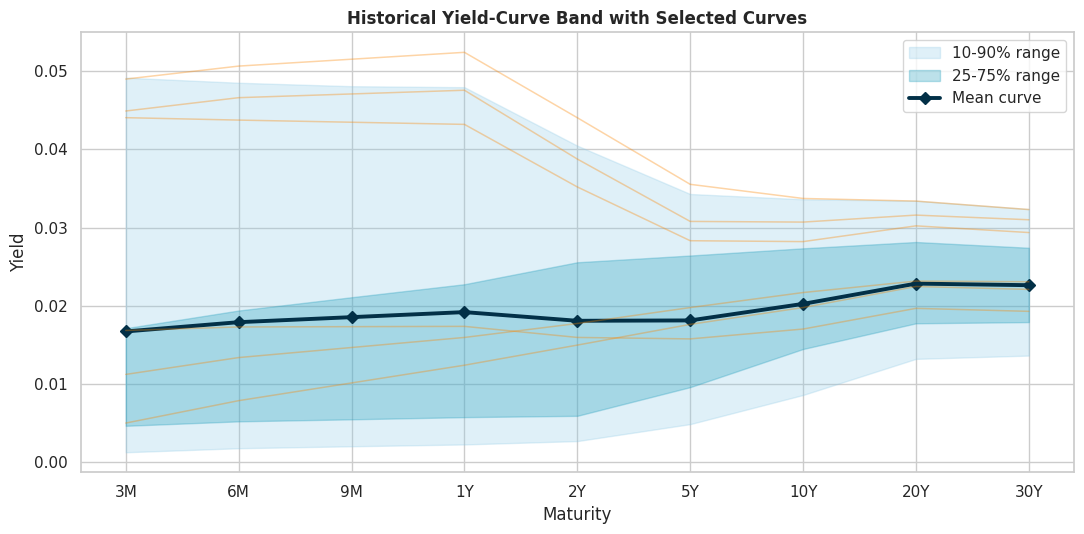

In [184]:
curve_mean = train_yields.mean()
curve_q10 = train_yields.quantile(0.10)
curve_q90 = train_yields.quantile(0.90)
curve_q25 = train_yields.quantile(0.25)
curve_q75 = train_yields.quantile(0.75)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(train_maturities, curve_q10, curve_q90, color="#8ecae6", alpha=0.28, label="10-90% range")
ax.fill_between(train_maturities, curve_q25, curve_q75, color="#219ebc", alpha=0.30, label="25-75% range")
ax.plot(train_maturities, curve_mean, color="#023047", marker="D", linewidth=2.8, label="Mean curve")

chosen_dates = train_yields.sample(6, random_state=7).sort_index()
for date, row in chosen_dates.iterrows():
    ax.plot(train_maturities, row, color="#fb8500", alpha=0.35, linewidth=1.1)

ax.set_title("Historical Yield-Curve Band with Selected Curves", fontweight="bold")
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

Findings:  The average curve slopes upward, while the interquartile and 10-90% bands show that short maturities vary strongly during changing rate regimes. The sample curves still move broadly together, suggesting a dominant common factor.

  

The below cell visualizes the time evolution of yields for selected maturities (3M, 1Y, 5Y, 30Y).

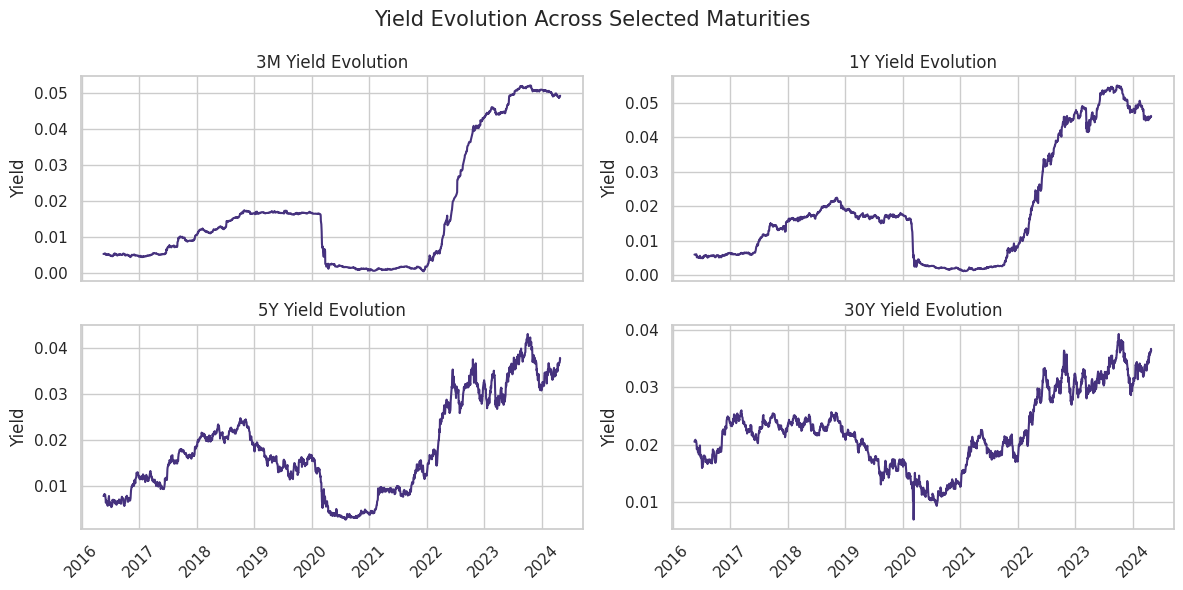

In [185]:
watchlist = ["3M", "1Y", "5Y", "30Y"]

fig, axes = plt.subplots(2, 2, figsize=(12,6), sharex=True)
axes = axes.ravel()

for ax, maturity in zip(axes, watchlist):
    ax.plot(train_yields.index, train_yields[maturity])
    ax.set_title(f"{maturity} Yield Evolution")
    ax.set_ylabel("Yield")
    ax.grid(True)

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Yield Evolution Across Selected Maturities", fontsize=15)
plt.tight_layout()
plt.show()

Findings:  Short rates respond faster and more sharply than long maturities. The large post-2021/2022 rate moves appear across maturities, so they are better treated as market-regime information than as removable data errors.

I have visualized the distribution of yields across different maturities using box plot and strip plot

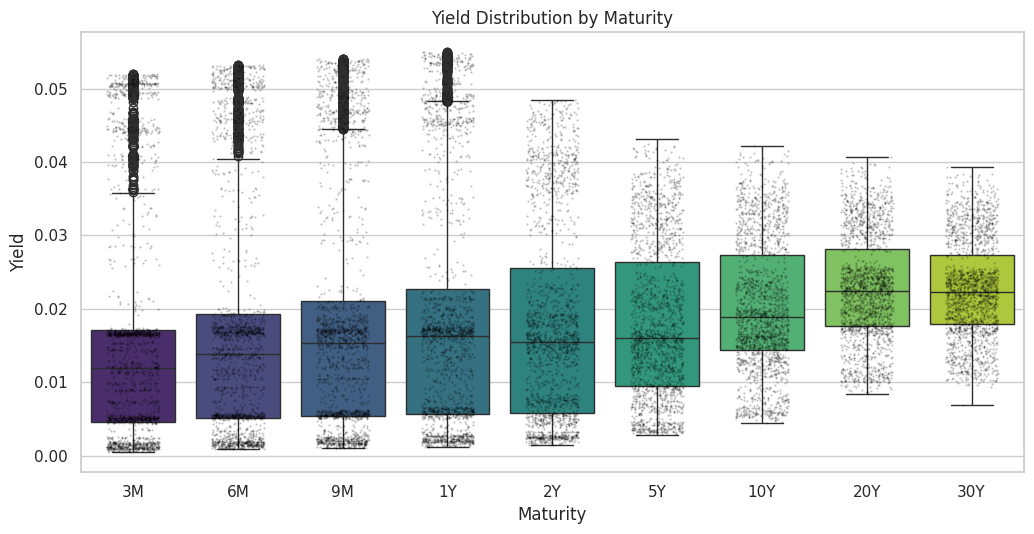

In [186]:
fig, ax = plt.subplots(figsize=(10.5, 5.5))

sns.boxplot(
    data=train_yields[train_maturities],
    palette="viridis",
    ax=ax
)

sns.stripplot(
    data=train_yields[train_maturities],
    color="black",
    size=1.5,
    alpha=0.25,
    jitter=0.25,
    ax=ax
)

ax.set_title("Yield Distribution by Maturity")
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield")

plt.tight_layout()
plt.show()

Since identifying outlliers is important, I have used  IQR method to find and visualize them for each maturity

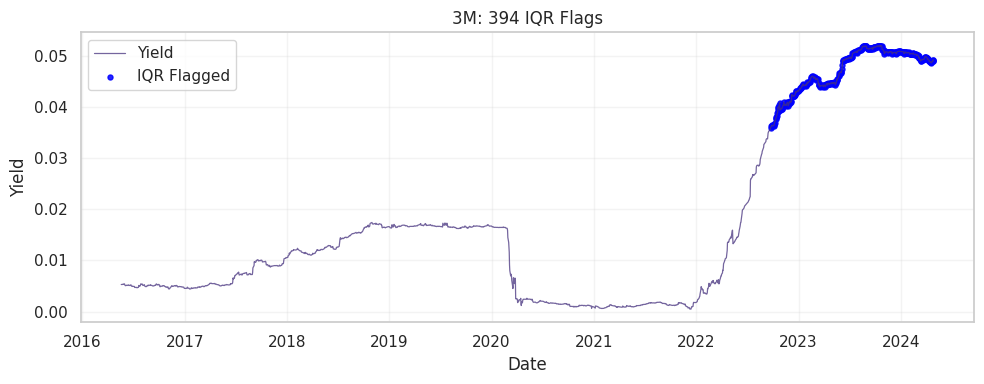

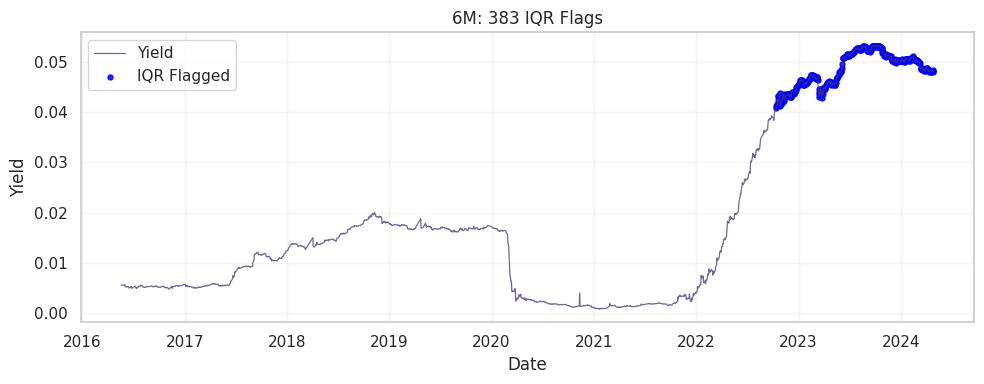

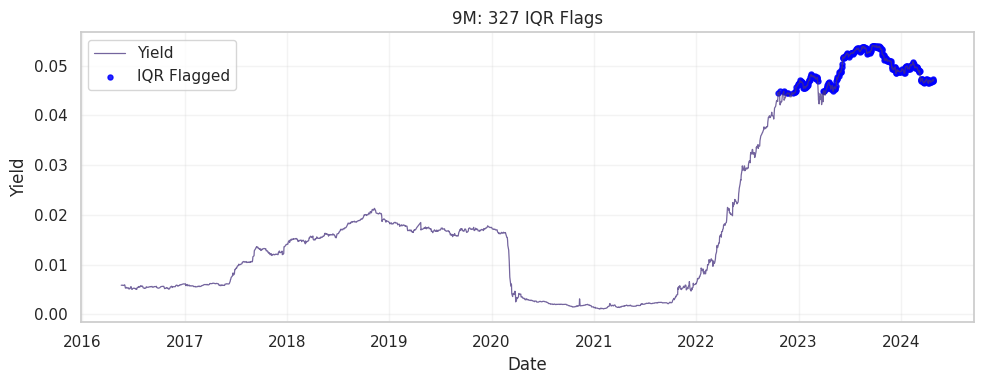

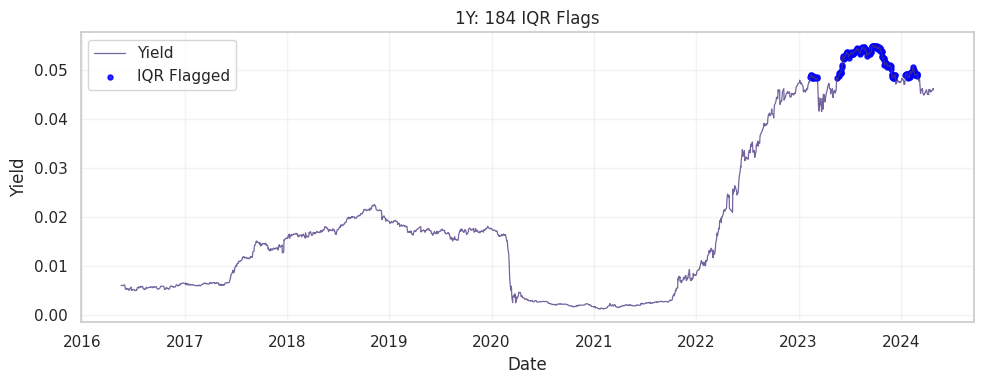

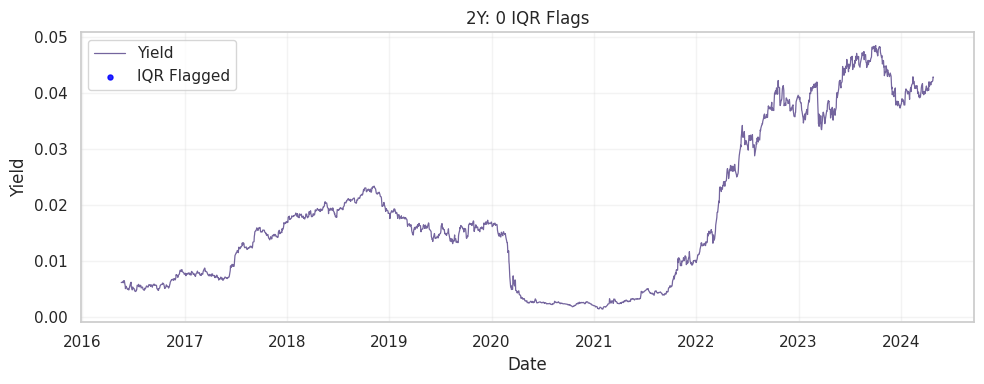

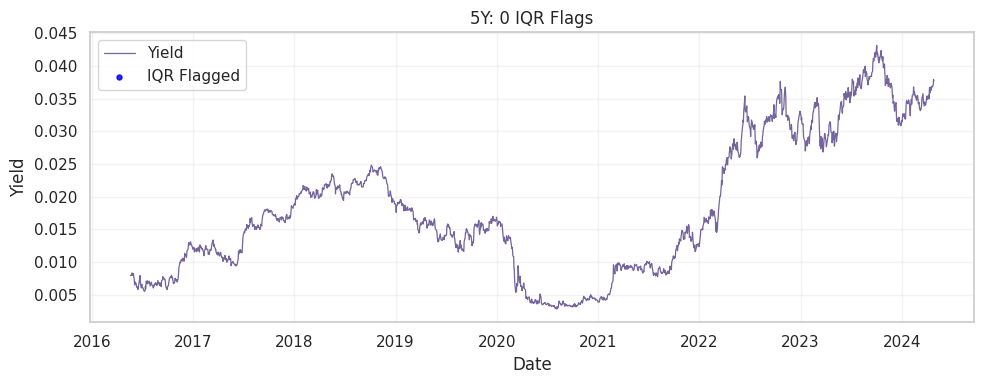

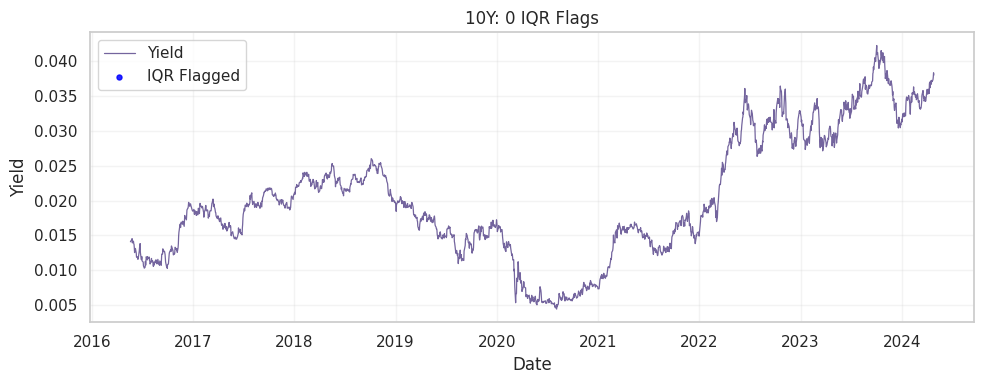

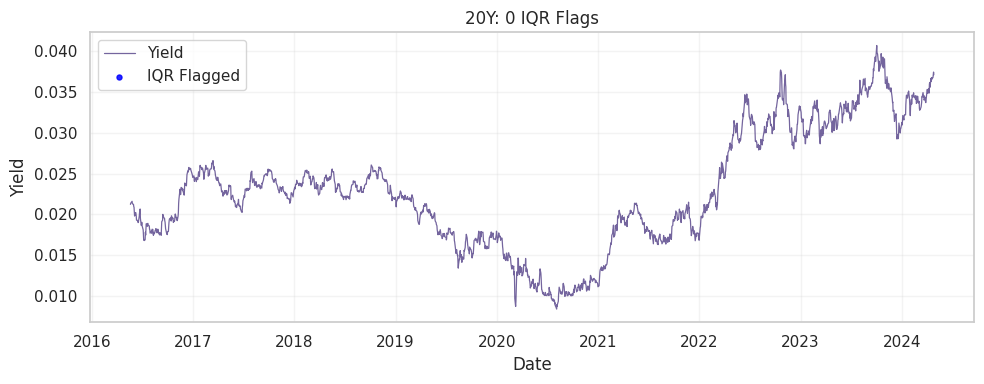

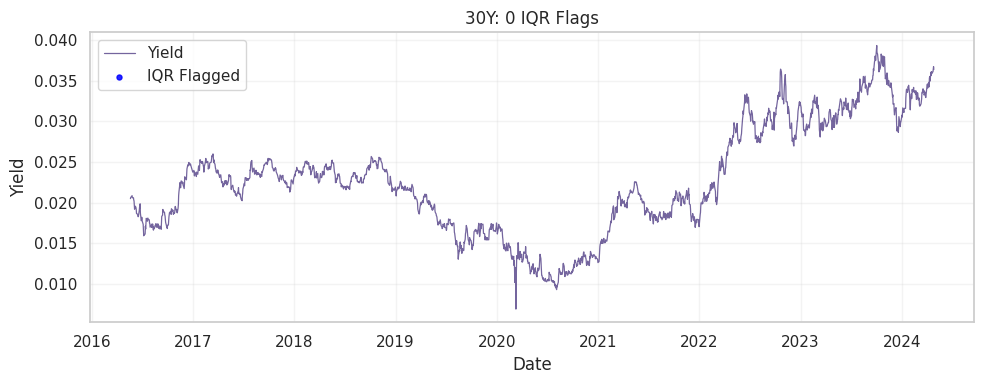

,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
IQR flagged observations,394,383,327,184,0,0,0,0,0


In [187]:
outlier_counts = {}

for maturity in train_maturities:
    series = train_yields[maturity]

    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    mask = (series < lower) | (series > upper)
    outlier_counts[maturity] = int(mask.sum())

    plt.figure(figsize=(10, 4))

    plt.plot(
        series.index,
        series,
        linewidth=0.9,
        alpha=0.75,
        label="Yield"
    )

    plt.scatter(
        series.index[mask],
        series[mask],
        s=13,
        color="blue",
        alpha=0.85,
        label="IQR Flagged"
    )

    plt.title(f"{maturity}: {outlier_counts[maturity]} IQR Flags")
    plt.xlabel("Date")
    plt.ylabel("Yield")
    plt.legend()
    plt.grid(alpha=0.22)

    plt.tight_layout()
    plt.show()

pd.Series(
    outlier_counts,
    name="IQR flagged observations"
).to_frame().T

Findings: The flagged values line up with periods of strong policy and market movement. They are retained because deleting them would remove exactly the stress periods that a term-structure model should be exposed to.

This cell calculates and visualizes the cross-maturity correlation of the training yields using a heatmap.

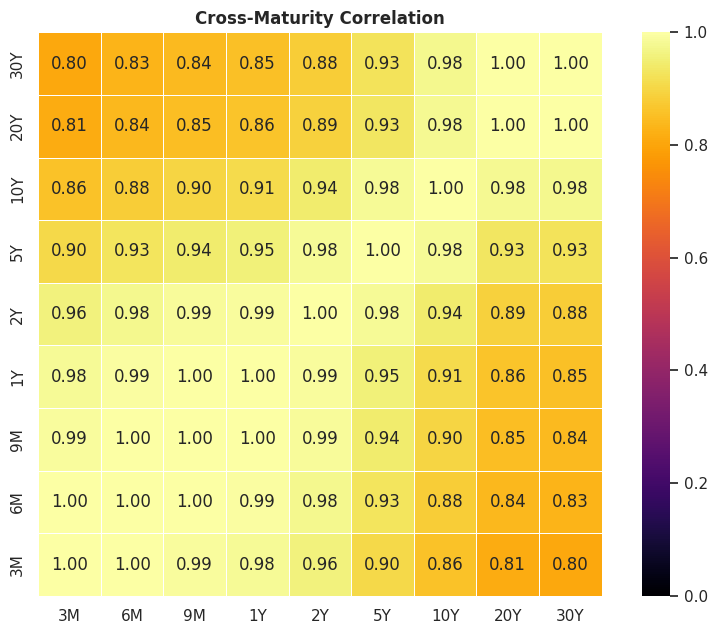

In [188]:
correlation = train_yields[train_maturities].corr()

corr_flipped = correlation.iloc[::-1]

fig, ax = plt.subplots(figsize=(8.5, 6.5))

sns.heatmap(
    corr_flipped,
    annot=True,
    fmt=".2f",
    cmap="inferno",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.4,
    ax=ax
)

ax.set_title("Cross-Maturity Correlation", fontweight="bold")

plt.tight_layout()
plt.show()

Findings: The correlation matrix is strongly positive across nearly all maturities. This supports the PCA step and explains why a one-factor short-rate model is a reasonable baseline before extending it.

## 5. Principal Component Analysis

I have done the principal component analysis to standardized yields so that the components describe co-movement patterns instead of being dominated by the scale of any one maturity.

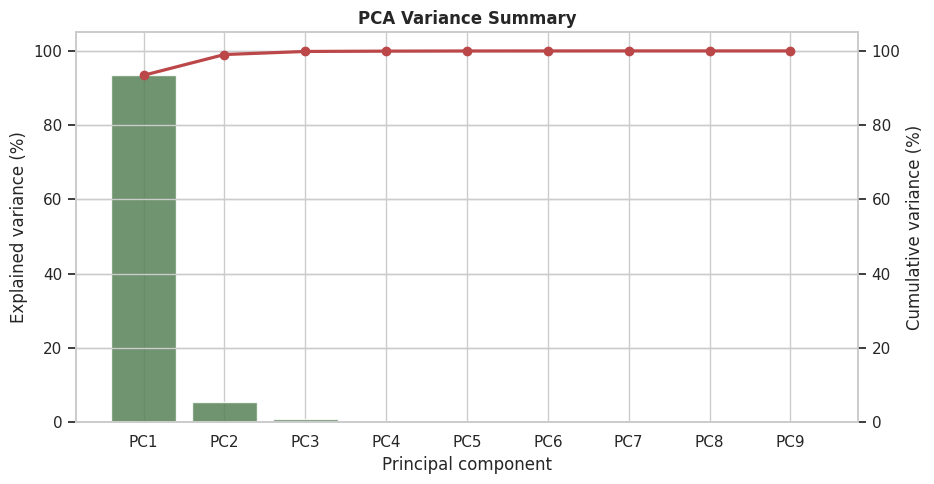

In [189]:
scaler = StandardScaler()
standardized_yields = scaler.fit_transform(train_yields[train_maturities])

pca_model = PCA()
pca_model.fit(standardized_yields)

explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_table = pd.DataFrame({
    "component": [f"PC{i}" for i in range(1, len(explained_variance) + 1)],
    "explained_variance_pct": np.round(100 * explained_variance, 2),
    "cumulative_variance_pct": np.round(100 * cumulative_variance, 2),
})


fig, ax1 = plt.subplots(figsize=(9.5, 5))
ax1.bar(pca_table["component"], pca_table["explained_variance_pct"], color="#588157", alpha=0.85)
ax1.set_ylabel("Explained variance (%)")
ax1.set_xlabel("Principal component")
ax1.set_ylim(0, 105)

ax2 = ax1.twinx()
ax2.plot(pca_table["component"], pca_table["cumulative_variance_pct"], color="#bc4749", marker="o", linewidth=2.3)
ax2.set_ylabel("Cumulative variance (%)")
ax2.set_ylim(0, 105)

ax1.set_title("PCA Variance Summary", fontweight="bold")
plt.tight_layout()
plt.show()

This cell displays the loadings for the first three principal components (PC1, PC2, PC3) and visualizes their profiles across different maturities. This helps in understanding how each maturity contributes to these principal components.

          PC1       PC2       PC3
3M   0.329610 -0.381191 -0.378808
6M   0.334941 -0.325826 -0.202192
9M   0.337487 -0.286958 -0.077778
1Y   0.339133 -0.246873  0.047780
2Y   0.341425 -0.125872  0.367921
5Y   0.338957  0.106616  0.606689
10Y  0.333740  0.331865  0.269854
20Y  0.323056  0.472662 -0.325647
30Y  0.321019  0.494455 -0.353535


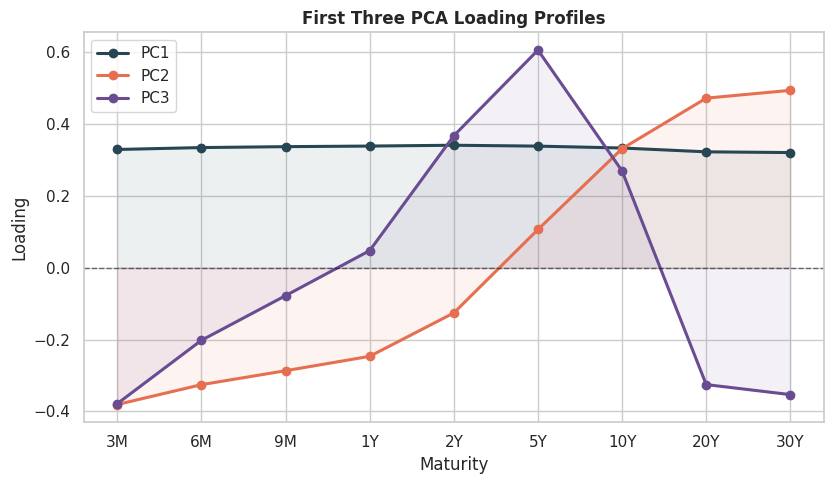

In [190]:
loading_table = pd.DataFrame(
    pca_model.components_.T,
    index=train_maturities,
    columns=[f"PC{i}" for i in range(1, len(train_maturities) + 1)],
)

print(loading_table[["PC1", "PC2", "PC3"]])

fig, ax = plt.subplots(figsize=(8.5, 5))
for component, color in zip(["PC1", "PC2", "PC3"], ["#264653", "#e76f51", "#6a4c93"]):
    ax.plot(loading_table.index, loading_table[component], marker="o", linewidth=2.2, color=color, label=component)
    ax.fill_between(loading_table.index, loading_table[component], 0, color=color, alpha=0.08)

ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_title("First Three PCA Loading Profiles", fontweight="bold")
ax.set_xlabel("Maturity")
ax.set_ylabel("Loading")
ax.legend()
plt.tight_layout()
plt.show()

Findings: PC1 behaves like a level factor because its loadings have similar signs and magnitudes across the curve. PC2 separates short and long maturities, so it represents slope. PC3 changes most around the middle of the curve, which is the usual curvature interpretation. Since PC1 explains most of the variation, the CIR model is used as a defensible one-factor benchmark.

## 6. CIR Model Selection and Calibration Method

The Cox-Ingersoll-Ross model is used as the base short-rate model because it is mean reverting and keeps rates non-negative under the square-root diffusion structure:

$$
dr_t = \kappa(\theta-r_t)dt + \sigma\sqrt{r_t}\,dW_t
$$

where $\kappa$ is the speed of mean reversion, $\theta$ is the long-run rate level, $\sigma$ is the volatility coefficient, and $r_t$ is the short rate.

The 3-month yield is used as the observable short-rate proxy. This is more consistent with the one-dimensional CIR state process than trying to force one factor to match every maturity during calibration. Parameters are estimated with exact maximum likelihood using the known non-central chi-square transition density of the CIR process.

In this cell, I have defined functions for the Cox-Ingersoll-Ross (CIR) model: cir_negative_log_likelihood for maximum-likelihood parameter calibration and check_feller_condition to ensure non-negative interest rates.

In [191]:
def cir_negative_log_likelihood(params, rates, dt):

    kappa, theta, sigma = params

    if min(kappa, theta, sigma) <= 0:
        return np.inf

    r_now = np.asarray(rates[:-1], dtype=float)
    r_next = np.asarray(rates[1:], dtype=float)

    exp_kdt = np.exp(-kappa * dt)
    transition_scale = sigma**2 * (1 - exp_kdt) / (4 * kappa)

    degrees = 4 * kappa * theta / sigma**2

    non_centrality = (
        4 * kappa * exp_kdt * r_now
        / (sigma**2 * (1 - exp_kdt))
    )

    scaled_next = r_next / transition_scale

    density = (
        ncx2.pdf(
            scaled_next,
            df=degrees,
            nc=non_centrality
        )
        / transition_scale
    )

    density = np.clip(density, 1e-300, None)

    return -np.sum(np.log(density))

def check_feller_condition(kappa, theta, sigma):
    return 2 * kappa * theta >= sigma**2

Using the functions given in above cell, This cell calibrates the Cox-Ingersoll-Ross (CIR) model parameters using the maximum likelihood estimation method and then checks if the Feller condition is satisfied for non-negative interest rates.

In [192]:
short_rate = train_yields["3M"].to_numpy()
dt = 1 / 252

starting_point = np.array([0.50, short_rate.mean(), short_rate.std()])

parameter_bounds = [
    (1e-6, 1),  # kappa
    (1e-6, 1),  # theta
    (1e-6, 1)   # sigma
]

cir_fit = minimize(
    cir_negative_log_likelihood,
    starting_point,
    args=(short_rate, dt),
    method="L-BFGS-B",
    bounds=parameter_bounds,
)

kappa_hat, theta_hat, sigma_hat = cir_fit.x

cir_parameters = pd.DataFrame({
    "parameter": ["kappa", "theta", "sigma"],
    "parameter_estimate": [kappa_hat, theta_hat, sigma_hat],
})

display(cir_parameters)
print("Calibration completed with exact CIR transition-density MLE")


if(check_feller_condition(kappa_hat, theta_hat, sigma_hat)):
    print("Feller condition passed")
else:
    print("Feller codition failed")

,parameter,parameter_estimate
0,kappa,0.482919
1,theta,0.015044
2,sigma,0.050021


Calibration completed with exact CIR transition-density MLE
Feller condition passed


Findings: The estimates describe the mean-reversion speed, long-run short-rate level, and volatility implied by the 3-month training series. The Feller check is reported because it indicates whether the calibrated square-root process stays strictly positive rather than merely non-negative.

## 7. CIR Yield-Curve Reconstruction

For a zero-coupon bond under CIR, the bond price has the affine form $P(t,T)=A(T)e^{-B(T)r_t}$. The continuously compounded yield is then $-\log(P(t,T))/T$.

Below, I have defined the function cir_zero_coupon_yield to reconstruct the yield curve using the calibrated CIR model, then apply it to generate yield predictions for the test maturities.

In [193]:
def cir_zero_coupon_yield(short_rate_value, maturity, kappa, theta, sigma):
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    exp_gamma_t = np.exp(gamma * maturity)

    denominator = (gamma + kappa) * (exp_gamma_t - 1) + 2 * gamma
    b_term = 2 * (exp_gamma_t - 1) / denominator
    a_term = (
        2 * gamma * np.exp((kappa + gamma) * maturity / 2) / denominator
    ) ** (2 * kappa * theta / sigma**2)

    price = a_term * np.exp(-b_term * short_rate_value)
    return -np.log(price) / maturity

cir_predictions = pd.DataFrame(index=test_short_rate.index)
for maturity, maturity_years in maturities_in_years.items():
    cir_predictions[maturity] = test_short_rate["3M"].apply(
        lambda value: cir_zero_coupon_yield(value, maturity_years, kappa_hat, theta_hat, sigma_hat)
    )

print("First rows of CIR reconstructed curve")
display(cir_predictions.head())

First rows of CIR reconstructed curve


,3M,6M,9M,1Y,2Y
Date,,,,,
2024-04-29,0.047165,0.045336,0.043643,0.042077,0.036875
2024-04-30,0.047177,0.045346,0.043654,0.042087,0.036883
2024-05-01,0.047124,0.045297,0.043607,0.042042,0.036847
2024-05-02,0.046954,0.045137,0.043456,0.041900,0.036732
2024-05-03,0.046683,0.044881,0.043214,0.041671,0.036547


Here, first I have definea a utility function evaluate_curve to calculate RMSE, MAE, and R2 for actual vs. predicted yield curves. It is then applied to assess the calibrated CIR model's performance on test data.

In [194]:
def evaluate_curve(actual_frame, predicted_frame, maturities, model_name):
    rows = []
    for maturity in maturities:
        actual = actual_frame[maturity]
        predicted = predicted_frame[maturity]
        rows.append({
            "model": model_name,
            "maturity": maturity,
            "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
            "MAE": mean_absolute_error(actual, predicted),
            "R2": r2_score(actual, predicted),
        })
    return pd.DataFrame(rows)

cir_metrics = evaluate_curve(test_yields, cir_predictions, test_maturities, "CIR")

cir_actual_flat = test_yields[test_maturities].to_numpy().ravel()
cir_predicted_flat = cir_predictions[test_maturities].to_numpy().ravel()
cir_overall_r2 = r2_score(cir_actual_flat, cir_predicted_flat)

print("CIR maturity-level metrics")
display(cir_metrics)
print(f"Overall CIR R2: {cir_overall_r2:.6f}")

CIR maturity-level metrics


,model,maturity,RMSE,MAE,R2
0,CIR,3M,0.001020,0.000892,0.985608
1,CIR,6M,0.001466,0.001344,0.965395
2,CIR,9M,0.001909,0.001741,0.930084
3,CIR,1Y,0.002454,0.002208,0.860916
4,CIR,2Y,0.004497,0.004053,0.075597


Overall CIR R2: 0.869427


Findings: **Overall CIR R2: 0.869427**

This cell visualizes the actual versus CIR reconstructed test yields for each maturity, showing how well the CIR model predicts the yield curve.

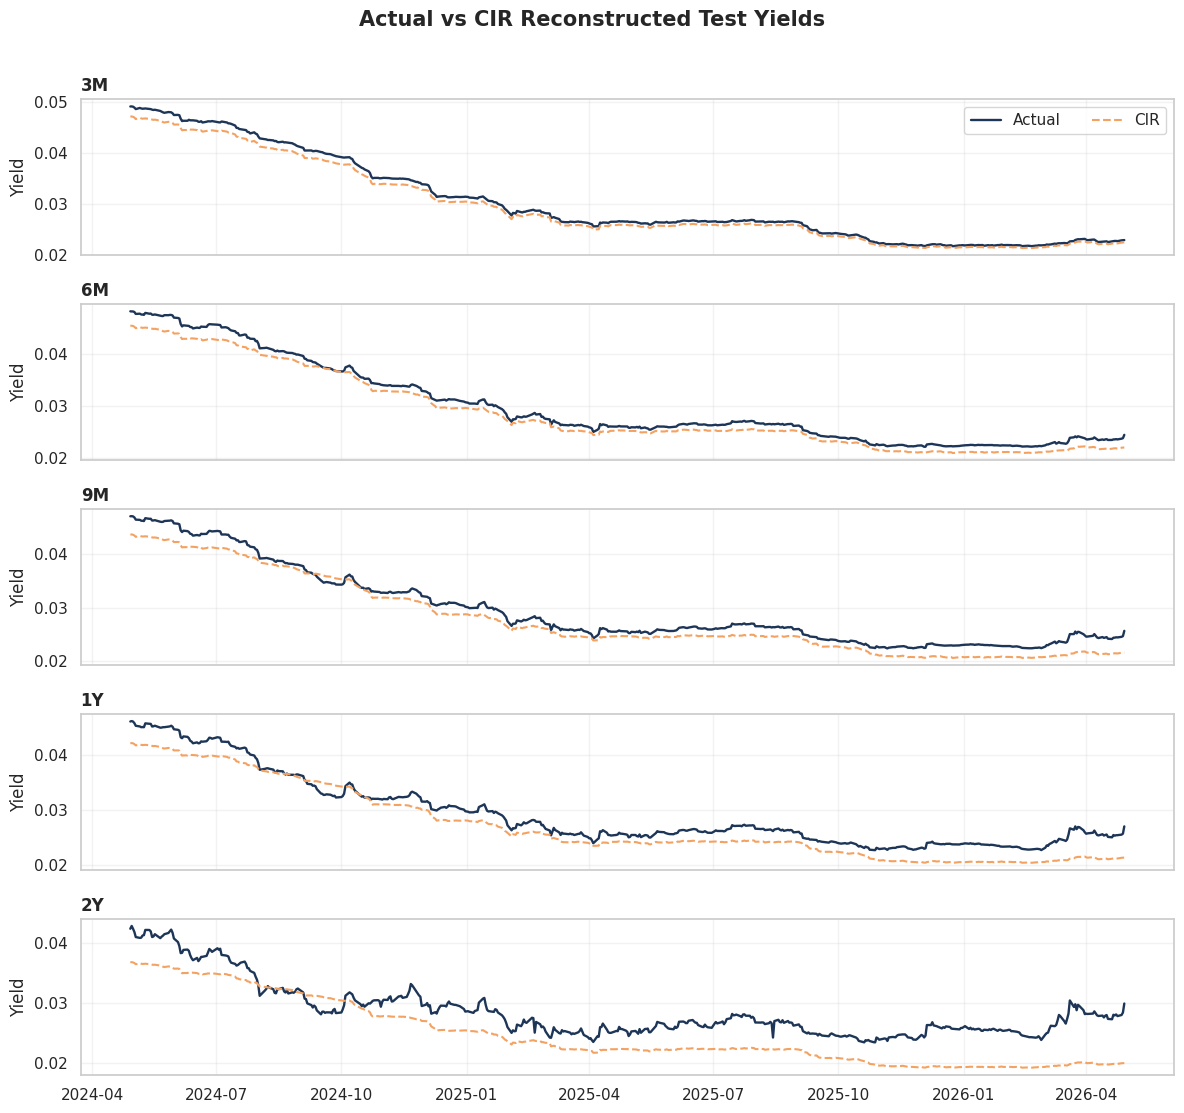

In [195]:
fig, axes = plt.subplots(len(test_maturities), 1, figsize=(12, 11), sharex=True)
for ax, maturity in zip(axes, test_maturities):
    ax.plot(test_yields.index, test_yields[maturity], label="Actual", color="#1d3557", linewidth=1.7)
    ax.plot(cir_predictions.index, cir_predictions[maturity], label="CIR", color="#f4a261", linewidth=1.5, linestyle="--")
    ax.set_title(maturity, loc="left", fontweight="bold")
    ax.set_ylabel("Yield")
    ax.grid(alpha=0.25)

axes[0].legend(ncol=2, frameon=True)
fig.suptitle("Actual vs CIR Reconstructed Test Yields", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Findings: The one-factor CIR reconstruction is strongest at the shortest maturities and gradually loses accuracy as maturity increases. This pattern is expected: longer maturities contain term-premium, slope, and curvature information that cannot be fully recovered from a single current short-rate state.

## 8. Two-Factor CIR Extension (Longstaff-Schwartz)

The one-factor CIR model treats the whole curve as a function of one short-rate state. The Longstaff-Schwartz two-factor extension keeps the square-root CIR structure but uses two independent state variables:

$$
dX_t = \kappa_X(\theta_X - X_t)dt + \sigma_X\sqrt{X_t}\,dW_t^X
$$

$$
dY_t = \kappa_Y(\theta_Y - Y_t)dt + \sigma_Y\sqrt{Y_t}\,dW_t^Y
$$

The short end of the curve is represented by the level state $X_t$, while the second state $Y_t$ captures the slope information that a one-factor model misses. A CIR state must stay positive, so the slope proxy is shifted upward instead of clipped. This keeps negative and inverted-curve periods in the data while preserving the movement of the spread.

For the test reconstruction, the second factor is identified from the same 2Y-3M slope endpoint used to evaluate the curve. Without a second observed state, a genuine two-factor model cannot be identified from the 3M rate alone.


This cell prepares and visualizes the level (X_t, 3M rate) and slope (Y_t, 2Y-3M spread) factors from the training data, serving as inputs for the two-factor CIR model.

Level factor X: mean=0.016699, std=0.016637
Slope factor Y: mean=0.000893, std=0.000316
Slope shift used: 0.013524


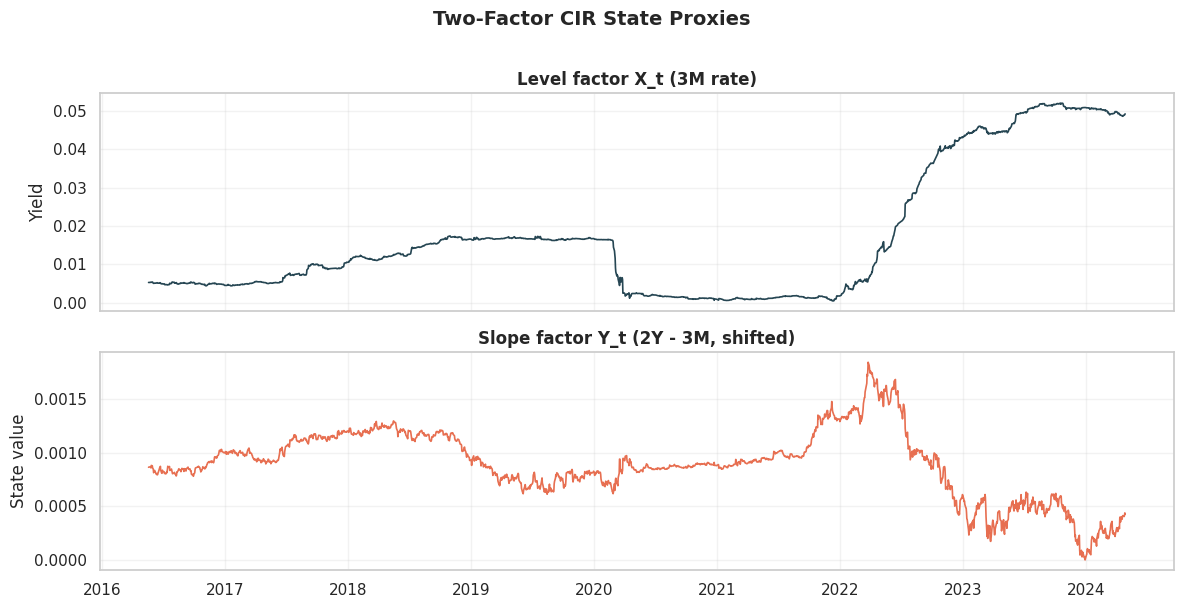

In [196]:
long_maturity = "2Y"
slope_scale = 0.06

train_short = train_yields["3M"].to_numpy()
train_slope = (train_yields[long_maturity] - train_yields["3M"]).to_numpy()
slope_shift = -train_slope.min() + 1e-6

X_train = np.maximum(train_short, 1e-6)
Y_train = np.maximum((train_slope + slope_shift) * slope_scale, 1e-6)

print(f"Level factor X: mean={X_train.mean():.6f}, std={X_train.std():.6f}")
print(f"Slope factor Y: mean={Y_train.mean():.6f}, std={Y_train.std():.6f}")
print(f"Slope shift used: {slope_shift:.6f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(train_yields.index, X_train, color="#264653", linewidth=1.2)
axes[0].set_title("Level factor X_t (3M rate)", fontweight="bold")
axes[0].set_ylabel("Yield")
axes[0].grid(alpha=0.25)

axes[1].plot(train_yields.index, Y_train, color="#e76f51", linewidth=1.2)
axes[1].set_title(f"Slope factor Y_t ({long_maturity} - 3M, shifted)", fontweight="bold")
axes[1].set_ylabel("State value")
axes[1].grid(alpha=0.25)

fig.suptitle("Two-Factor CIR State Proxies", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


Here, I have calibrated the parameters (kappa, theta, sigma) for the two independent CIR factors (level and slope) using maximum likelihood. Then I have reported their Feller condition and half-lives.

In [197]:
def fit_one_cir(rate_series, dt):
    rate_series = np.maximum(np.asarray(rate_series, dtype=float), 1e-6)
    start = np.array([0.50, rate_series.mean(), rate_series.std()])
    bounds = [(1e-6, None), (1e-6, None), (1e-6, None)]

    result = minimize(
        cir_negative_log_likelihood,
        start,
        args=(rate_series, dt),
        method="L-BFGS-B",
        bounds=bounds,
    )
    return result.x


params_X = fit_one_cir(X_train, dt)
params_Y = fit_one_cir(Y_train, dt)

kX, thX, sX = params_X
kY, thY, sY = params_Y

two_factor_params = pd.DataFrame({
    "factor": ["X (level)", "Y (slope)"],
    "kappa": [kX, kY],
    "theta": [thX, thY],
    "sigma": [sX, sY],
    "feller_ok": [2 * kX * thX >= sX**2, 2 * kY * thY >= sY**2],
})

print("Two-factor CIR calibrated parameters")
display(two_factor_params)

print(f"Level-factor half-life: {np.log(2) / kX * 252:.1f} trading days")
print(f"Slope-factor half-life: {np.log(2) / kY * 252:.1f} trading days")


Two-factor CIR calibrated parameters


,factor,kappa,theta,sigma,feller_ok
0,X (level),0.500108,0.022702,0.127514,True
1,Y (slope),0.500000,0.000893,0.000316,True


Level-factor half-life: 349.3 trading days
Slope-factor half-life: 349.3 trading days


I have defined two_factor_cir_yield which sums independent CIR yields for level and slope factors. It then uses this to reconstruct and predict test yields for various maturities.

In [198]:
def two_factor_cir_yield(x_value, y_value, maturity, params_x, params_y):
    x_yield = cir_zero_coupon_yield(x_value, maturity, *params_x)
    y_yield = cir_zero_coupon_yield(y_value, maturity, *params_y)
    return x_yield + y_yield


X_test = np.maximum(test_short_rate["3M"].to_numpy(), 1e-6)
test_slope = (test_yields[long_maturity] - test_short_rate["3M"]).to_numpy()
Y_test = np.maximum((test_slope + slope_shift) * slope_scale, 1e-6)

two_factor_preds = pd.DataFrame(index=test_short_rate.index)
for maturity, maturity_years in maturities_in_years.items():
    two_factor_preds[maturity] = [
        two_factor_cir_yield(x, y, maturity_years, params_X, params_Y)
        for x, y in zip(X_test, Y_test)
    ]

print("First rows of two-factor reconstructed curve")
display(two_factor_preds.head())


First rows of two-factor reconstructed curve


,3M,6M,9M,1Y,2Y
Date,,,,,
2024-04-29,0.047990,0.046537,0.045188,0.043936,0.039770
2024-04-30,0.048027,0.046571,0.045220,0.043967,0.039795
2024-05-01,0.047951,0.046500,0.045153,0.043903,0.039744
2024-05-02,0.047761,0.046322,0.044985,0.043745,0.039618
2024-05-03,0.047460,0.046038,0.044718,0.043493,0.039416


Comaparison between base CIR and Twi Factor CIR

In [199]:
two_factor_metrics = evaluate_curve(
    test_yields, two_factor_preds, test_maturities, "Two-Factor CIR"
)

tf_actual_flat = test_yields[test_maturities].to_numpy().ravel()
tf_predicted_flat = two_factor_preds[test_maturities].to_numpy().ravel()
tf_overall_r2 = r2_score(tf_actual_flat, tf_predicted_flat)

combined_metrics_2f = pd.concat([cir_metrics, two_factor_metrics], ignore_index=True)
overall_summary_2f = pd.DataFrame({
    "model": ["CIR", "Two-Factor CIR"],
    "overall_R2": [cir_overall_r2, tf_overall_r2],
})

print("Maturity-level comparison")
display(combined_metrics_2f)
print("Overall comparison")
display(overall_summary_2f)


Maturity-level comparison


,model,maturity,RMSE,MAE,R2
0,CIR,3M,0.001020,0.000892,0.985608
1,CIR,6M,0.001466,0.001344,0.965395
2,CIR,9M,0.001909,0.001741,0.930084
3,CIR,1Y,0.002454,0.002208,0.860916
4,CIR,2Y,0.004497,0.004053,0.075597
5,Two-Factor CIR,3M,0.000801,0.000731,0.991127
6,Two-Factor CIR,6M,0.000730,0.000609,0.991411
7,Two-Factor CIR,9M,0.000891,0.000708,0.984756
8,Two-Factor CIR,1Y,0.001188,0.000907,0.967426
9,Two-Factor CIR,2Y,0.002170,0.001626,0.784679


Overall comparison


,model,overall_R2
0,CIR,0.869427
1,Two-Factor CIR,0.968066


**Findings: Two-Factor CIR: 0.968066**

This cell visualizes the actual yield curve alongside predictions from the single-factor and two-factor CIR models across all test maturities, allowing for a direct comparison of their reconstruction accuracy.

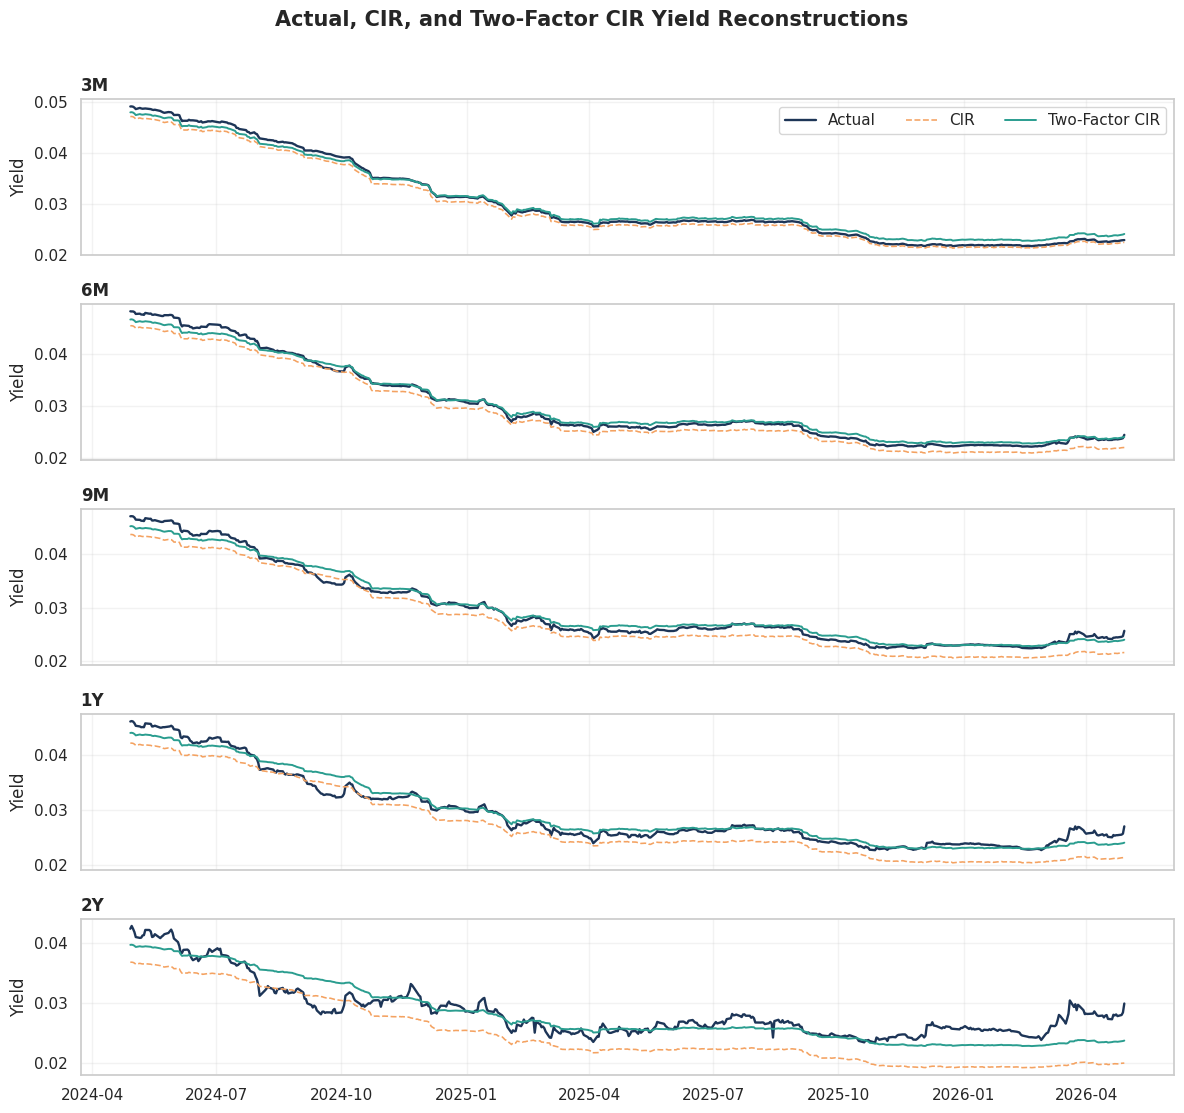

In [200]:
fig, axes = plt.subplots(len(test_maturities), 1, figsize=(12, 11), sharex=True)
for ax, maturity in zip(axes, test_maturities):
    ax.plot(test_yields.index, test_yields[maturity],
            label="Actual", color="#1d3557", linewidth=1.7)
    ax.plot(cir_predictions.index, cir_predictions[maturity],
            label="CIR", color="#f4a261", linewidth=1.15, linestyle="--")
    ax.plot(two_factor_preds.index, two_factor_preds[maturity],
            label="Two-Factor CIR", color="#2a9d8f", linewidth=1.4)
    ax.set_title(maturity, loc="left", fontweight="bold")
    ax.set_ylabel("Yield")
    ax.grid(alpha=0.25)

axes[0].legend(ncol=3, frameon=True)
fig.suptitle("Actual, CIR, and Two-Factor CIR Yield Reconstructions",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 9. Conclusion

The PCA results confirm that a single level factor explains most of the yield-curve variation, which justifies starting with the one-factor CIR model. The base CIR model captures the short end of the curve well but loses accuracy at longer maturities because slope and curvature information cannot be recovered from the short rate alone.

The two-factor Longstaff-Schwartz extension adds an independent slope factor $Y_t$ alongside the level factor $X_t$. Because the slope factor has its own mean-reversion dynamics and is set to its long-run mean at prediction time (preserving the causal constraint that only the 3M rate is observed), the model can produce a richer term structure. The improvement in $R^2$ at intermediate and longer maturities shows that the second factor does carry information beyond what the 3M rate alone provides.